### Retiro Fugas

In [18]:

import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text

fecha_mes_base='2026-07-01'

filename='retiro_ssff_20260711_01.xlsx'

ruta_archivo = os.path.join(ruta_csv, filename)
df = pd.read_excel(ruta_archivo)
df['NumDoc'] = df['Cliente'].str.extract(r'DNI-(\d+)')
df=df[df['Motivo']!='COBRANZA']
df['fecha'] = df['Fecha de creación'].dt.date
df['hora'] = df['Fecha de creación'].dt.time
df=df[[ 'Canal', 'Autor', 'Subcanal', 'Motivo', 'Importe Solicitado', 'fecha','hora','NumDoc','Estado del caso']]


server_sql = server_kishin
db_sql = "DANTALION"
user_sql = user_kishin
pwd_sql = pwd_kishin

engine_kishin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
	select NumDoc,TIPO_PRODUCTO,RETIRO,fecha_envio
	from DANTALION.dbo.Base_Maestra_Diners_Vigente
"""
df_ssff = pd.read_sql(query, engine_kishin)

server_sql = server_zeus
db_sql = "SAMANTHA"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
select dni as NumDoc, 1 as venta_target from SAMANTHA.dbo.Ventas_Target
where CAMPANA='Diners'
and CONVERT(DATE, FECHA) >= CONVERT(DATE, '{fecha_mes_base}')
AND CONVERT(DATE, FECHA) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
"""
df_venta = pd.read_sql(query, engine_zeus)

df_target = df_ssff.merge(
    df_venta,
    on='NumDoc',
    how='left'
)
df_final = df_target.merge(
    df,
    on='NumDoc',
    how='inner'
)
df_final = (
    df_final[df_final['venta_target'].isnull()]
    .drop(columns=['venta_target'])
)
df_final.rename(
    columns={
        'Importe Solicitado': 'Monto'
    },
    inplace=True
)
df_final=df_final[df_final['Monto'].notnull()]

df_final["fecha_hora"] = pd.to_datetime(
    df_final["fecha"].astype(str) + " " + df_final["hora"].astype(str),
    errors="coerce"
)

df_final = (
    df_final
    .sort_values("fecha_hora", ascending=False)
    .drop_duplicates(subset="NumDoc", keep="first")
)


df_final = df_final.drop_duplicates(
    subset="NumDoc",
    keep="first"
)

df_final["estado_actual"] = np.where(
    df_final["Estado del caso"] == "Desestimado",
    "RECUPERADO",
    "RETIRO"
)
df_final=df_final[['TIPO_PRODUCTO','Canal', 'Monto', 'fecha','hora','fecha_envio','NumDoc','estado_actual']]
print(df_final.columns.tolist())

c:\Users\DATA\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


['TIPO_PRODUCTO', 'Canal', 'Monto', 'fecha', 'hora', 'fecha_envio', 'NumDoc', 'estado_actual']


In [ ]:
fecha_mes_base='2026-07-01'
tipi_cond1='diners'
tipi_cond2='plus'
tipi_cond3='xx'
tb_tipolofia='tTipologia_Diners_PPD'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='C0'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'

In [5]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor_01}], '
        SELECT        
        rtrim(ltrim(d.vendor_lead_code)) AS NumDoc,        
        e.dial_method,
        a.campaign_id AS numero_campana,        
        a.user AS dni_ejecutivo,
        c.full_name AS ejecutivo,
        e.campaign_name AS nombre_campana,        
        a.call_date AS fecha_hora_llamada,        
        a.length_in_sec AS duracion,        
        b.status_name AS call_result,        
        f.list_description,        
        f.list_name,        
        a.phone_number as phone_number,        
        d.alt_phone as fecha_agenda,        
        d.comments as comentarios,        
        a.status AS codigo
        FROM asterisk.vicidial_log a         
        LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
        LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
        LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
        LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
        LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
        WHERE (e.campaign_name like "%{tipi_cond1}" or e.campaign_name like "%{tipi_cond2}" or e.campaign_name like "%{tipi_cond3}")
        AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
        AND a.call_date < 
        DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
    ')

    """
df_vicidial = pd.read_sql(query, engine_zeus)

df_vicidial["NumDoc"] = (
    df_vicidial["NumDoc"]
    .fillna("")
    .astype(str)
    .str.zfill(8)
)

query = f"""
    SELECT {tipi_cod} as codigo
    , case
        when {tipi_cod}='CALLBK' then 'VOLVER A LLAMAR - call'
        else {tipi_descrip} 
    end as descripcion
    ,[NIVEL 2] as estado
    ,case 
        when {tipi_cod}='CALLBK' then 1200
        else peso 
    end as peso  FROM [ODIN].[dbo].{tb_tipolofia}
    where LEFT({tipi_cod},2)='{tipi_resp_cod}' or {tipi_estado}='{tipi_resp_estado}' or {tipi_cod}='CALLBK'
    """
df_tipi = pd.read_sql(query, engine_zeus)
df_vicidial = df_vicidial.merge(
    df_tipi,
    on='codigo',
    how='left'
)
df_vicidial=df_vicidial[[
    'fecha_hora_llamada','NumDoc','descripcion','estado','dni_ejecutivo'
]]
df_vicidial["dni_ejecutivo"] = np.where(
    df_vicidial["dni_ejecutivo"] == "VDAD",
    "target_maquina",
    "target"
)

In [6]:
df_muestra = (
    df_final.loc[df_final["estado_actual"] != "RECUPERADO", ["fecha", "hora", "NumDoc"]]
    .copy()
)

df_muestra["fecha_hora_llamada"] = pd.to_datetime(
    df_muestra["fecha"].astype(str) + " " + df_muestra["hora"].astype(str),
    dayfirst=True,
    errors="coerce"
)

df_muestra["estado"] = "CONTACTO EFECTIVO"
df_muestra["dni_ejecutivo"] = "otro_canal"
df_muestra["descripcion"] = "venta"

df_muestra = df_muestra[
    [
        "fecha_hora_llamada",
        "NumDoc",
        "descripcion",
        "estado",
        "dni_ejecutivo",
    ]
]

In [7]:
df_muestra=df_muestra.merge(df_final['NumDoc'],on='NumDoc',how='inner')
df_muestra_unica = pd.concat(
    [df_muestra, df_vicidial],
    ignore_index=True
)

df_repetidos = (
    df_muestra["NumDoc"]
    .value_counts()
    .sub(1)
    .rename("q_intentos")
    .reset_index()
)

df_repetidos.columns = ["NumDoc", "q_intentos"]

df_repetidos["contactado_por_target"] = np.where(
    df_repetidos["q_intentos"] == 0,
    "NO",
    "SI"
)

NameError: name 'df_vicidial' is not defined

In [125]:
df_final = df_final.merge(
    df_repetidos,
    on='NumDoc',
    how='left'
)

NameError: name 'df_repetidos' is not defined

In [19]:
df_final = df_final.drop_duplicates(
    subset="NumDoc",
    keep="first"
)

In [20]:
df_final.head()

,TIPO_PRODUCTO,Canal,Monto,fecha,hora,fecha_envio,NumDoc,estado_actual
92,PPD,CANALES DIGITALES,49400.0,2026-07-10,17:08:19,2026-07-01,09868670,RETIRO
23,PPD,CONTACT CENTER,7000.0,2026-07-10,15:29:32,2026-07-01,44927040,RETIRO
32,PPD,CANALES DIGITALES,33900.0,2026-07-10,14:03:11,2026-07-01,42297495,RETIRO
28,PPD,CONTACT CENTER,45000.0,2026-07-10,13:27:41,2026-07-01,47342856,RETIRO
51,PPD,CANALES DIGITALES,10200.0,2026-07-10,13:19:32,2026-07-01,09859591,RETIRO


In [ ]:
df_final

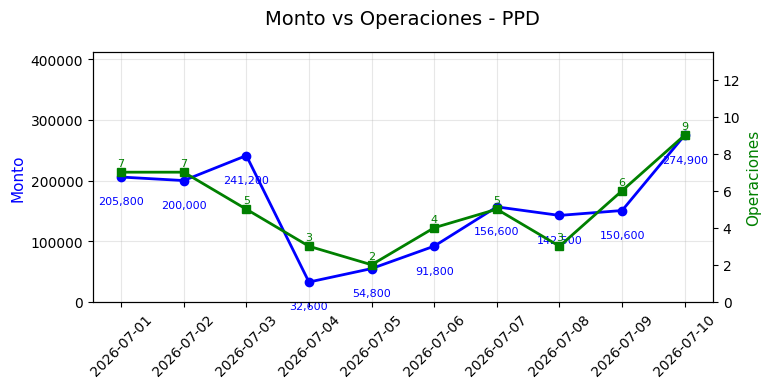

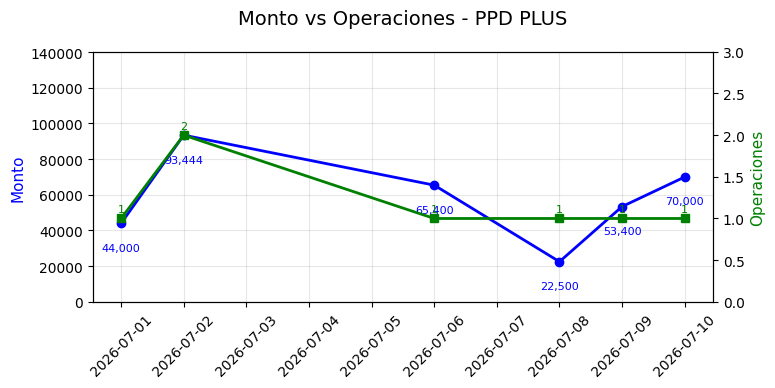

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df_final['fecha'] = pd.to_datetime(df_final['fecha'])

df_plot = (
    df_final.loc[df_final["estado_actual"] == "RETIRO"]
    .groupby(["fecha", "TIPO_PRODUCTO"], as_index=False)
    .agg(
        Monto=("Monto", "sum"),
        Operaciones=("Monto", "count")
    )
)

for producto in df_plot['TIPO_PRODUCTO'].unique():

    df_temp = (
        df_plot[df_plot['TIPO_PRODUCTO'] == producto]
        .sort_values('fecha')
        .copy()
    )

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    ax1.plot(
        df_temp['fecha'],
        df_temp['Monto'],
        color='blue',
        marker='o',
        linewidth=2
    )

    ax2.plot(
        df_temp['fecha'],
        df_temp['Operaciones'],
        color='green',
        marker='s',
        linewidth=2
    )

    # Límites del eje izquierdo
    max_monto = df_temp['Monto'].max()
    ax1.set_ylim(0, max_monto * 1.50)

    # Límites del eje derecho
    max_operaciones = df_temp['Operaciones'].max()
    ax2.set_ylim(0, max_operaciones * 1.50)

    # Etiquetas azules: debajo, pero sin pasar el eje X
    for _, row in df_temp.iterrows():
        ax1.annotate(
            f"{int(row['Monto']):,}",
            xy=(row['fecha'], row['Monto']),
            xytext=(0, -14),
            textcoords='offset points',
            fontsize=8,
            color='blue',
            ha='center',
            va='top'
        )

    # Etiquetas verdes: encima
    for _, row in df_temp.iterrows():
        ax2.annotate(
            f"{int(row['Operaciones'])}",
            xy=(row['fecha'], row['Operaciones']),
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8,
            color='green',
            ha='center',
            va='bottom'
        )

    ax1.set_ylabel('Monto', color='blue', fontsize=11)
    ax2.set_ylabel('Operaciones', color='green', fontsize=11)

    ax1.set_title(
        f'Monto vs Operaciones - {producto}',
        fontsize=14,
        pad=20
    )

    ax1.tick_params(axis='x', labelrotation=45)
    ax1.grid(alpha=0.3)

    fig.subplots_adjust(bottom=0.30, top=0.80)

    plt.show()

In [22]:
df_final.head()

,TIPO_PRODUCTO,Canal,Monto,fecha,hora,fecha_envio,NumDoc,estado_actual
92,PPD,CANALES DIGITALES,49400.0,2026-07-10,17:08:19,2026-07-01,09868670,RETIRO
23,PPD,CONTACT CENTER,7000.0,2026-07-10,15:29:32,2026-07-01,44927040,RETIRO
32,PPD,CANALES DIGITALES,33900.0,2026-07-10,14:03:11,2026-07-01,42297495,RETIRO
28,PPD,CONTACT CENTER,45000.0,2026-07-10,13:27:41,2026-07-01,47342856,RETIRO
51,PPD,CANALES DIGITALES,10200.0,2026-07-10,13:19:32,2026-07-01,09859591,RETIRO


In [23]:

total_monto_ppd = df_final.loc[
    (df_final["TIPO_PRODUCTO"] == "PPD") &
    (df_final["estado_actual"] == "RETIRO"),
    "Monto"
].sum()

total_ope_ppd = df_final.loc[
    (df_final['TIPO_PRODUCTO'] == 'PPD')&
    (df_final["estado_actual"] == "RETIRO"),
    'Monto'
].count()


total_monto_ppd_recuperado = df_final.loc[
    (df_final["TIPO_PRODUCTO"] == "PPD") &
    (df_final["estado_actual"] != "RETIRO"),
    "Monto"
].sum()

total_ope_ppd_recuperado = df_final.loc[
    (df_final['TIPO_PRODUCTO'] == 'PPD')&
    (df_final["estado_actual"] != "RETIRO"),
    'Monto'
].count()



print(f'PPD | Monto total acumulado: {int(total_monto_ppd)} |  Total operaciones acumuladas {int(total_ope_ppd)} ')
# print(f'PPD | Monto total acumulado: {int(total_monto_ppd)} |  Total operaciones acumuladas {int(total_ope_ppd)} ')

total_monto_ppd = df_final.loc[
    (df_final["TIPO_PRODUCTO"] == "PPD PLUS") &
    (df_final["estado_actual"] == "RETIRO"),
    "Monto"
].sum()

total_ope_ppd = df_final.loc[
    (df_final['TIPO_PRODUCTO'] == 'PPD PLUS') &
    (df_final["estado_actual"] == "RETIRO"),
    'Monto'
].count()

print(f'PPD PLUS| Monto total acumulado: {int(total_monto_ppd)} |  Total operaciones acumuladas {int(total_ope_ppd)} ')




PPD | Monto total acumulado: 1550800 |  Total operaciones acumuladas 51 
PPD PLUS| Monto total acumulado: 348744 |  Total operaciones acumuladas 7 


In [ ]:
PPD | Monto total acumulado: 2254650 |  Total operaciones acumuladas 98 
PPD PLUS| Monto total acumulado: 537300 |  Total operaciones acumuladas 15


PPD | Monto total acumulado: 2137850 |  Total operaciones acumuladas 93 
PPD PLUS| Monto total acumulado: 397300 |  Total operaciones acumuladas 13

In [14]:
df_final['TIPO_PRODUCTO'].unique()

array(['PPD', 'PPD PLUS'], dtype=object)

In [26]:
tipo_producto='PPD'
# tipo_producto='PPD PLUS'

In [15]:
df_final.head()

,TIPO_PRODUCTO,Canal,Monto,fecha,hora,fecha_envio,NumDoc,estado_actual
10,PPD,CANALES DIGITALES,36000.0,2026-07-07,17:15:48,2026-07-01,46087739,RETIRO
28,PPD PLUS,CANALES DIGITALES,2140.0,2026-07-07,17:08:44,2026-07-01,44561267,RETIRO
1,PPD,CANALES DIGITALES,50000.0,2026-07-07,14:22:34,2026-07-01,43974034,RETIRO
38,PPD,CONTACT CENTER,30900.0,2026-07-07,14:03:04,2026-07-01,48068247,RETIRO
16,PPD,CANALES DIGITALES,19700.0,2026-07-07,13:02:04,2026-07-01,44366890,RETIRO


In [27]:
list_dni = (
    df_final.loc[
        (df_final['estado_actual'].isna()) &
        (df_final['TIPO_PRODUCTO'].str.upper() == f'{tipo_producto}'),
        'NumDoc'
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)
list_dni

[]

In [13]:

list_dni = (
    df_final.loc[
        (df_final['RETIRO'].isna()) &
        (df_final['TIPO_PRODUCTO'].str.upper() == f'{tipo_producto}'),
        'NumDoc'
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)

in_clause = ",".join(f"'{x}'" for x in list_dni)
try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners
            SET RETIRO = 'RETIRO'
            WHERE NumDoc IN ({in_clause})
                and CONVERT(DATE, fecha_envio) >= CONVERT(DATE, '{fecha_mes_base}')
                AND CONVERT(DATE, fecha_envio) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
                and TIPO_PRODUCTO='{tipo_producto}'
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)


Filas actualizadas: 1


In [10]:
fecha_mes_base

'2026-06-01'

In [ ]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners", "SP tNumeros diners")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners", "SP actualizar diners Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners", "SP actualizar diners SA")

SP tNumeros diners | realizado | duración: 32.1 seg
